## Combining new features with existing one

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost.callback import EarlyStopping
from sklearn.model_selection import RandomizedSearchCV

In [2]:
old_data = pd.read_csv(
    "data_processed/final_model_ready_full.csv"
)

print("Shape:", old_data.shape)
old_data.head()


Shape: (16206, 45)


,GEOID,population,households,median_income,workers,mean_commute_time,vehicles_total,state,county,tract,...,ports_per_1000_pop,stations_per_1000_pop,establishments_per_1000_pop,retail_per_1000_pop,food_per_1000_pop,service_per_1000_pop,infrastructure_pressure,pop_to_business_ratio,dcfc_share,demand_index
0,6029004402,4667.0,1316.0,29515.0,1947.0,1723.0,1316.0,CA,29.0,4402.0,...,0.428541,0.428541,0.376050,0.078084,0.065150,0.043114,0.048797,1693.995970,0.666667,16.645024
1,6047000802,4597.0,1532.0,77143.0,2354.0,1884.0,1532.0,CA,47.0,802.0,...,0.000000,0.000000,6.025225,1.031824,0.762924,0.659742,2.168054,160.185608,0.000000,19.125185
2,6085501402,2716.0,839.0,93092.0,1458.0,1222.0,839.0,CA,85.0,501402.0,...,0.000000,0.000000,67.197027,8.068609,7.551390,9.971973,0.441909,14.800515,0.000000,19.852939
3,6005000102,2338.0,960.0,69500.0,993.0,690.0,960.0,CA,5.0,102.0,...,0.000000,0.000000,40.199470,8.238253,13.668841,4.912506,20.483437,24.614060,0.000000,19.179186
4,6029004901,6074.0,1602.0,47167.0,2889.0,2439.0,1602.0,CA,29.0,4901.0,...,2.304906,0.164636,1.369278,0.274506,0.271904,0.165224,0.037124,651.926821,0.000000,18.323410


In [13]:
new_data = pd.read_csv("data_processed/all_states_cleaned_added_features.csv")
print("Shape:", new_data.shape)
new_data.head()

Shape: (16206, 46)


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,...,pct_work_from_home,jobs_total,high_wage_jobs,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd
0,36,47,700,36047000700,7.0,Census Tract 7,G5020,S,176774,0,...,0.234234,688.0,384.0,0.558140,49.987826,94.130495,291.470,20.991754,0.465199,13.833333
1,36,47,900,36047000900,9.0,Census Tract 9,G5020,S,163469,0,...,0.370717,10532.0,6033.0,0.572826,57.411727,130.306203,117.350,250.379143,4.944074,17.000000
2,36,47,1100,36047001100,11.0,Census Tract 11,G5020,S,168507,0,...,0.225083,62244.0,55424.0,0.890431,22.207282,338.228855,0.000,1607.530925,79.941876,15.666667
3,36,47,1300,36047001300,13.0,Census Tract 13,G5020,S,293167,0,...,0.395112,3730.0,3104.0,0.832172,10.517950,328.144151,132.770,16.567403,0.646459,17.750000
4,36,47,2000,36047002000,20.0,Census Tract 20,G5020,S,154138,0,...,0.083682,1562.0,872.0,0.558259,13.744700,83.330888,185.075,77.946761,6.864401,14.583333


In [14]:
new_data.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'population',
       'median_home_value', 'median_income', 'hh_100k_150k', 'hh_150k_plus',
       'total_households', 'bachelor', 'masters_plus', 'edu_total',
       'owner_occupied', 'occupied_total', 'single_detached', 'housing_total',
       'drive_alone', 'work_from_home', 'commute_total', 'state', 'county',
       'tract', 'pct_high_income', 'pct_bachelor_plus', 'pct_owner_occupied',
       'pct_single_family', 'pct_drive_alone', 'pct_work_from_home',
       'jobs_total', 'high_wage_jobs', 'high_wage_share', 'D1A', 'D3B', 'D4A',
       'D1C', 'D2A_JPHH', 'NatWalkInd'],
      dtype='str')

In [5]:
old_data.columns

Index(['GEOID', 'population', 'households', 'median_income', 'workers',
       'mean_commute_time', 'vehicles_total', 'state', 'county', 'tract',
       'state_code', 'station_count', 'total_ports', 'l2_ports', 'dcfc_ports',
       'dist_nearest_charger_km', 'dist_nearest_dcfc_km',
       'establishments_total', 'retail_establishments', 'food_establishments',
       'service_establishments', 'log_population', 'log_households',
       'log_workers', 'log_vehicles_total', 'log_total_ports', 'log_l2_ports',
       'log_dcfc_ports', 'log_station_count', 'log_establishments_total',
       'log_retail_establishments', 'log_food_establishments',
       'log_service_establishments', 'log_dist_nearest_charger_km',
       'log_dist_nearest_dcfc_km', 'ports_per_1000_pop',
       'stations_per_1000_pop', 'establishments_per_1000_pop',
       'retail_per_1000_pop', 'food_per_1000_pop', 'service_per_1000_pop',
       'infrastructure_pressure', 'pop_to_business_ratio', 'dcfc_share',
       'demand_in

In [15]:
old_data["GEOID"] = old_data["GEOID"].astype(str).str.zfill(11)
new_data["GEOID"] = new_data["GEOID"].astype(str).str.zfill(11)

print(old_data["GEOID"].dtype, new_data["GEOID"].dtype)

str str


In [16]:
common = set(old_data["GEOID"]).intersection(set(new_data["GEOID"]))

print("Common GEOIDs:", len(common))
print("Old rows:", len(old_data))
print("New rows:", len(new_data))

Common GEOIDs: 16206
Old rows: 16206
New rows: 16206


In [17]:
merged_df = old_data.merge(
    new_data,
    on="GEOID",
    how="left",
    suffixes=("", "_new")
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (16206, 90)


,GEOID,population,households,median_income,workers,mean_commute_time,vehicles_total,state,county,tract,...,pct_work_from_home,jobs_total,high_wage_jobs,high_wage_share,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd
0,06029004402,4667.0,1316.0,29515.0,1947.0,1723.0,1316.0,CA,29.0,4402.0,...,0.002316,948.0,417.0,0.439873,3.813267,102.216662,513.645,1.693441,0.697247,13.666667
1,06047000802,4597.0,1532.0,77143.0,2354.0,1884.0,1532.0,CA,47.0,802.0,...,0.022314,227.0,69.0,0.303965,2.571004,85.614348,836.860,0.538363,0.209103,11.166667
2,06085501402,2716.0,839.0,93092.0,1458.0,1222.0,839.0,CA,85.0,501402.0,...,0.098155,239.0,56.0,0.234310,6.965281,135.405093,297.060,2.516033,0.389289,15.166667
3,06005000102,2338.0,960.0,69500.0,993.0,690.0,960.0,CA,5.0,102.0,...,0.199536,521.0,73.0,0.140115,0.133182,2.978485,NaN,0.028175,0.600668,4.833333
4,06029004901,6074.0,1602.0,47167.0,2889.0,2439.0,1602.0,CA,29.0,4901.0,...,0.021268,1749.0,950.0,0.543168,5.252226,94.248209,469.390,3.997857,1.155547,9.208333


In [18]:
[col for col in merged_df.columns if col.endswith("_new")]

['population_new', 'median_income_new', 'state_new', 'county_new', 'tract_new']

In [19]:
# Identify new columns not already in old_data
new_columns = [col for col in new_data.columns if col not in old_data.columns]

merged_df = old_data.merge(
    new_data[["GEOID"] + new_columns],
    on="GEOID",
    how="left"
)

print("Merged shape:", merged_df.shape)

Merged shape: (16206, 85)


In [20]:
print("Missing after merge:")
print(merged_df.isna().mean().sort_values(ascending=False).head(10))

Missing after merge:
D4A                0.406701
NatWalkInd         0.225966
D2A_JPHH           0.225966
D1C                0.225966
D3B                0.225966
D1A                0.225966
high_wage_share    0.000679
high_wage_jobs     0.000679
jobs_total         0.000679
ALAND              0.000000
dtype: float64


In [21]:
merged_df.columns


Index(['GEOID', 'population', 'households', 'median_income', 'workers',
       'mean_commute_time', 'vehicles_total', 'state', 'county', 'tract',
       'state_code', 'station_count', 'total_ports', 'l2_ports', 'dcfc_ports',
       'dist_nearest_charger_km', 'dist_nearest_dcfc_km',
       'establishments_total', 'retail_establishments', 'food_establishments',
       'service_establishments', 'log_population', 'log_households',
       'log_workers', 'log_vehicles_total', 'log_total_ports', 'log_l2_ports',
       'log_dcfc_ports', 'log_station_count', 'log_establishments_total',
       'log_retail_establishments', 'log_food_establishments',
       'log_service_establishments', 'log_dist_nearest_charger_km',
       'log_dist_nearest_dcfc_km', 'ports_per_1000_pop',
       'stations_per_1000_pop', 'establishments_per_1000_pop',
       'retail_per_1000_pop', 'food_per_1000_pop', 'service_per_1000_pop',
       'infrastructure_pressure', 'pop_to_business_ratio', 'dcfc_share',
       'demand_in

In [58]:
target = ["total_ports"]

In [23]:
leakage_features = [
    "log_total_ports",
    "log_l2_ports",
    "log_dcfc_ports",
    "log_station_count",
    "ports_per_1000_pop",
    "stations_per_1000_pop",
    "dcfc_share",
    "infrastructure_pressure"
]

In [24]:
geo_columns = [
    "GEOID",
    "state", "county", "tract", "state_code",
    "STATEFP", "COUNTYFP", "TRACTCE",
    "NAME", "NAMELSAD", "MTFCC", "FUNCSTAT",
    "INTPTLAT", "INTPTLON"
]

In [25]:
redundant_columns = [
    "hh_100k_150k",
    "hh_150k_plus",
    "total_households",
    "bachelor",
    "masters_plus",
    "edu_total",
    "owner_occupied",
    "occupied_total",
    "single_detached",
    "housing_total",
    "drive_alone",
    "work_from_home",
    "commute_total",
    "high_wage_jobs"
]

In [26]:
demand_features = [
    "log_population",
    "log_vehicles_total",
    "median_income",
    "median_home_value",
    "mean_commute_time",
    "pct_high_income",
    "pct_bachelor_plus",
    "pct_owner_occupied",
    "pct_single_family",
    "pct_drive_alone",
    "pct_work_from_home"
]

In [38]:
economic_features = [
    "jobs_total",
    "log_establishments_total",
    "log_retail_establishments",
    "log_food_establishments",
    "log_service_establishments",
    "high_wage_share"
]

In [28]:
built_features = [
    "D1A",
    "D3B",
    "D4A",
    "D1C",
    "D2A_JPHH",
    "NatWalkInd"
]

In [29]:
spatial_features = [
    "log_dist_nearest_charger_km",
    "log_dist_nearest_dcfc_km",
    "ALAND"
]

In [59]:
model_features = (
    demand_features +
    economic_features +
    built_features +
    spatial_features +
    target
)

In [60]:
len(model_features)

27

In [61]:
model_features

['log_population',
 'log_vehicles_total',
 'median_income',
 'median_home_value',
 'mean_commute_time',
 'pct_high_income',
 'pct_bachelor_plus',
 'pct_owner_occupied',
 'pct_single_family',
 'pct_drive_alone',
 'pct_work_from_home',
 'jobs_total',
 'log_establishments_total',
 'log_retail_establishments',
 'log_food_establishments',
 'log_service_establishments',
 'high_wage_share',
 'D1A',
 'D3B',
 'D4A',
 'D1C',
 'D2A_JPHH',
 'NatWalkInd',
 'log_dist_nearest_charger_km',
 'log_dist_nearest_dcfc_km',
 'ALAND',
 'total_ports']

In [62]:
fianl_data = merged_df[model_features]

In [63]:
fianl_data.head()

,log_population,log_vehicles_total,median_income,median_home_value,mean_commute_time,pct_high_income,pct_bachelor_plus,pct_owner_occupied,pct_single_family,pct_drive_alone,...,D1A,D3B,D4A,D1C,D2A_JPHH,NatWalkInd,log_dist_nearest_charger_km,log_dist_nearest_dcfc_km,ALAND,total_ports
0,8.448486,7.183112,29515.0,188100.0,1723.0,0.019757,0.029261,0.421733,0.682848,0.855819,...,3.813267,102.216662,513.645,1.693441,0.697247,13.666667,0.136619,0.136619,1865739,2
1,8.433377,7.334982,77143.0,335200.0,1884.0,0.246084,0.234708,0.774804,0.867354,0.879606,...,2.571004,85.614348,836.860,0.538363,0.209103,11.166667,1.153117,1.153117,2321653,0
2,7.907284,6.733402,93092.0,960900.0,1222.0,0.239571,0.202001,0.439809,0.493522,0.724723,...,6.965281,135.405093,297.060,2.516033,0.389289,15.166667,0.365968,0.992233,522620,0
3,7.757479,6.867974,69500.0,334500.0,690.0,0.159375,0.229626,0.865625,0.951235,0.738979,...,0.133182,2.978485,NaN,0.028175,0.600668,4.833333,3.067282,3.543009,456204155,0
4,8.711937,7.379632,47167.0,207800.0,2439.0,0.067416,0.060996,0.486267,0.565735,0.504414,...,5.252226,94.248209,469.390,3.997857,1.155547,9.208333,0.442671,0.632365,1459379,14


In [64]:
fianl_data.isna().sum()

log_population                    0
log_vehicles_total                0
median_income                     0
median_home_value                 0
mean_commute_time                 0
pct_high_income                   0
pct_bachelor_plus                 0
pct_owner_occupied                0
pct_single_family                 0
pct_drive_alone                   0
pct_work_from_home                0
jobs_total                       11
log_establishments_total          0
log_retail_establishments         0
log_food_establishments           0
log_service_establishments        0
high_wage_share                  11
D1A                            3662
D3B                            3662
D4A                            6591
D1C                            3662
D2A_JPHH                       3662
NatWalkInd                     3662
log_dist_nearest_charger_km       0
log_dist_nearest_dcfc_km          0
ALAND                             0
total_ports                       0
dtype: int64

In [65]:
final_data = fianl_data.fillna(0)

In [66]:
final_data.isna().sum()

log_population                 0
log_vehicles_total             0
median_income                  0
median_home_value              0
mean_commute_time              0
pct_high_income                0
pct_bachelor_plus              0
pct_owner_occupied             0
pct_single_family              0
pct_drive_alone                0
pct_work_from_home             0
jobs_total                     0
log_establishments_total       0
log_retail_establishments      0
log_food_establishments        0
log_service_establishments     0
high_wage_share                0
D1A                            0
D3B                            0
D4A                            0
D1C                            0
D2A_JPHH                       0
NatWalkInd                     0
log_dist_nearest_charger_km    0
log_dist_nearest_dcfc_km       0
ALAND                          0
total_ports                    0
dtype: int64

In [67]:
percent_cols = [
    "pct_high_income",
    "pct_bachelor_plus",
    "pct_owner_occupied",
    "pct_single_family",
    "pct_drive_alone",
    "pct_work_from_home",
    "high_wage_share"
]

fianl_data[percent_cols] = final_data[percent_cols].clip(0, 1)

In [68]:
final_data["destination_intensity"] = (
    np.log1p(final_data["jobs_total"]).rank(pct=True) +
    final_data["log_retail_establishments"].rank(pct=True) +
    final_data["log_food_establishments"].rank(pct=True)
)/3

In [69]:
final_data["urban_intensity_index"] = (
    final_data["D1A"].rank(pct=True) +
    final_data["D3B"].rank(pct=True) +
    final_data["NatWalkInd"].rank(pct=True)
) / 3

In [70]:
final_data["charging_access_gap"] = (
    final_data["log_dist_nearest_charger_km"] +
    final_data["log_dist_nearest_dcfc_km"]
)

In [71]:
final_data.head()

,log_population,log_vehicles_total,median_income,median_home_value,mean_commute_time,pct_high_income,pct_bachelor_plus,pct_owner_occupied,pct_single_family,pct_drive_alone,...,D1C,D2A_JPHH,NatWalkInd,log_dist_nearest_charger_km,log_dist_nearest_dcfc_km,ALAND,total_ports,destination_intensity,urban_intensity_index,charging_access_gap
0,8.448486,7.183112,29515.0,188100.0,1723.0,0.019757,0.029261,0.421733,0.682848,0.855819,...,1.693441,0.697247,13.666667,0.136619,0.136619,1865739,2,0.198280,0.632307,0.273239
1,8.433377,7.334982,77143.0,335200.0,1884.0,0.246084,0.234708,0.774804,0.867354,0.879606,...,0.538363,0.209103,11.166667,1.153117,1.153117,2321653,0,0.096106,0.499064,2.306235
2,7.907284,6.733402,93092.0,960900.0,1222.0,0.239571,0.202001,0.439809,0.493522,0.724723,...,2.516033,0.389289,15.166667,0.365968,0.992233,522620,0,0.290263,0.802707,1.358201
3,7.757479,6.867974,69500.0,334500.0,690.0,0.159375,0.229626,0.865625,0.951235,0.738979,...,0.028175,0.600668,4.833333,3.067282,3.543009,456204155,0,0.407380,0.270229,6.610291
4,8.711937,7.379632,47167.0,207800.0,2439.0,0.067416,0.060996,0.486267,0.565735,0.504414,...,3.997857,1.155547,9.208333,0.442671,0.632365,1459379,14,0.278642,0.563372,1.075036


In [72]:
final_data.columns

Index(['log_population', 'log_vehicles_total', 'median_income',
       'median_home_value', 'mean_commute_time', 'pct_high_income',
       'pct_bachelor_plus', 'pct_owner_occupied', 'pct_single_family',
       'pct_drive_alone', 'pct_work_from_home', 'jobs_total',
       'log_establishments_total', 'log_retail_establishments',
       'log_food_establishments', 'log_service_establishments',
       'high_wage_share', 'D1A', 'D3B', 'D4A', 'D1C', 'D2A_JPHH', 'NatWalkInd',
       'log_dist_nearest_charger_km', 'log_dist_nearest_dcfc_km', 'ALAND',
       'total_ports', 'destination_intensity', 'urban_intensity_index',
       'charging_access_gap'],
      dtype='str')

In [ ]:
import os

output_path = "data_processed/final_model_data/final_data.csv"

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save CSV
final_data.to_csv(output_path, index=False, float_format="%.6f")

print("Saved to:", output_path)

Saved to: data_processed/final_model_data/final_data.csv


In [78]:
import json

columns = final_data.columns.tolist()

with open("data_processed/final_model_data/final_data_columns.json", "w") as f:
    json.dump(columns, f, indent=4)

# Model Trainning

In [79]:
# Target
y = final_data["total_ports"].copy()

# Features (drop target)
X = final_data.drop(columns=["total_ports"])

In [80]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16206, 29)
y shape: (16206,)


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [88]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

In [89]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (11344, 29)
Validation: (2431, 29)
Test: (2431, 29)


In [90]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model = XGBRegressor(
    objective="count:poisson",
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from 

In [91]:
y_val_pred = model.predict(X_val)

print("Validation MAE:", mean_absolute_error(y_val, y_val_pred))
print("Validation R2:", r2_score(y_val, y_val_pred))

Validation MAE: 4.01318883895874
Validation R2: 0.3792731761932373


In [92]:
print("Zero port %:", (y == 0).mean())

Zero port %: 0.6181044057756386


In [93]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

jobs_total                     0.367881
destination_intensity          0.090432
log_dist_nearest_charger_km    0.064352
ALAND                          0.054942
charging_access_gap            0.042751
log_dist_nearest_dcfc_km       0.022927
mean_commute_time              0.022277
D1A                            0.021146
high_wage_share                0.021093
D1C                            0.019320
log_food_establishments        0.019211
log_service_establishments     0.017958
D2A_JPHH                       0.017933
pct_drive_alone                0.016767
pct_single_family              0.016325
dtype: float32

# Optimizing Model

In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = XGBRegressor(
    objective="count:poisson",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=5,                # reduce depth
    min_child_weight=5,         # prevent overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,              # L1 regularization
    reg_lambda=2.0,             # stronger L2
    gamma=0.1,                  # split regularization
    random_state=42,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_val_pred = model.predict(X_val)

print("Optimized Validation MAE:", mean_absolute_error(y_val, y_val_pred))
print("Optimized Validation R2:", r2_score(y_val, y_val_pred))

Optimized Validation MAE: 4.037171840667725
Optimized Validation R2: 0.34776729345321655


## Letrs try Tweedie

In [96]:
model_tweedie = XGBRegressor(
    objective="reg:tweedie",
    tweedie_variance_power=1.3,   # between Poisson (1) and Gamma (2)
    n_estimators=2500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    early_stopping_rounds=100
)

model_tweedie.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_val_pred_tw = model_tweedie.predict(X_val)

print("Tweedie MAE:", mean_absolute_error(y_val, y_val_pred_tw))
print("Tweedie R2:", r2_score(y_val, y_val_pred_tw))

Tweedie MAE: 3.9218339920043945
Tweedie R2: 0.3402661681175232


## Trying to train with only important features

In [ ]:
top_features = [
    "jobs_total",
    "destination_intensity",
    "log_dist_nearest_charger_km",
    "ALAND",
    "charging_access_gap",
    "log_dist_nearest_dcfc_km",
    "mean_commute_time",
    "D1A",
    "high_wage_share",
    "D1C",
    "log_food_establishments",
    "log_service_establishments",
    "D2A_JPHH",
    "pct_drive_alone",
    "pct_single_family"
]

In [98]:
X_reduced = final_data[top_features].copy()
y = final_data["total_ports"].copy()

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_reduced, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [100]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_reduced = XGBRegressor(
    objective="count:poisson",
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    gamma=0.1,
    random_state=42,
    early_stopping_rounds=100
)

model_reduced.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [101]:
y_val_pred = model_reduced.predict(X_val)

print("Reduced Model MAE:", mean_absolute_error(y_val, y_val_pred))
print("Reduced Model R2:", r2_score(y_val, y_val_pred))

Reduced Model MAE: 4.338977336883545
Reduced Model R2: 0.40587103366851807


In [102]:
y_test_pred = model_reduced.predict(X_test)

print("Reduced Model MAE:", mean_absolute_error(y_test, y_test_pred))
print("Reduced Model R2:", r2_score(y_test, y_test_pred))

Reduced Model MAE: 4.3312201499938965
Reduced Model R2: 0.442505419254303


# Lets try two- Stage Model with top features

In [103]:
top_features = [
    "jobs_total",
    "destination_intensity",
    "log_dist_nearest_charger_km",
    "ALAND",
    "charging_access_gap",
    "log_dist_nearest_dcfc_km",
    "mean_commute_time",
    "D1A",
    "high_wage_share",
    "D1C",
    "log_food_establishments",
    "log_service_establishments",
    "D2A_JPHH",
    "pct_drive_alone",
    "pct_single_family"
]

X = final_data[top_features].copy()
y = final_data["total_ports"].copy()

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

## Classifier to check has port or not

In [105]:
y_train_bin = (y_train > 0).astype(int)
y_val_bin = (y_val > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

In [106]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

clf = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.5,
    random_state=42
)

clf.fit(X_train, y_train_bin)

val_proba = clf.predict_proba(X_val)[:, 1]

print("Stage 1 Validation AUC:", roc_auc_score(y_val_bin, val_proba))

Stage 1 Validation AUC: 0.9426360628424313


# REGRESSION

In [107]:
from xgboost import XGBRegressor

mask_train = y_train > 0

reg = XGBRegressor(
    objective="count:poisson",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42
)

reg.fit(X_train[mask_train], y_train[mask_train])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [108]:
from sklearn.metrics import r2_score, mean_absolute_error

val_proba = clf.predict_proba(X_val)[:, 1]
val_reg_pred = reg.predict(X_val)

val_final_pred = val_proba * val_reg_pred

print("Two-Stage Validation MAE:",
      mean_absolute_error(y_val, val_final_pred))

print("Two-Stage Validation R2:",
      r2_score(y_val, val_final_pred))

Two-Stage Validation MAE: 4.229740619659424
Two-Stage Validation R2: 0.4176986813545227


In [109]:
test_proba = clf.predict_proba(X_test)[:, 1]
test_reg_pred = reg.predict(X_test)

test_final_pred = test_proba * test_reg_pred

print("Two-Stage Test MAE:",
      mean_absolute_error(y_test, test_final_pred))

print("Two-Stage Test R2:",
      r2_score(y_test, test_final_pred))

Two-Stage Test MAE: 4.258416652679443
Two-Stage Test R2: 0.41733282804489136


# Saving single stage reduced model

In [110]:
import joblib
import os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model_reduced, os.path.join(MODEL_DIR, "xgb_total_ports_reduced.pkl"))

print("Model saved successfully.")

Model saved successfully.


In [111]:
joblib.dump(top_features, os.path.join(MODEL_DIR, "xgb_total_ports_features.pkl"))

print("Feature list saved.")

Feature list saved.


# Other Model

# 1. LightGBM

In [2]:
data = pd.read_csv('data_processed/final_model_data/final_data.csv')
data.head()

,log_population,log_vehicles_total,median_income,median_home_value,mean_commute_time,pct_high_income,pct_bachelor_plus,pct_owner_occupied,pct_single_family,pct_drive_alone,...,D1C,D2A_JPHH,NatWalkInd,log_dist_nearest_charger_km,log_dist_nearest_dcfc_km,ALAND,total_ports,destination_intensity,urban_intensity_index,charging_access_gap
0,8.448486,7.183112,29515.0,188100.0,1723.0,0.019757,0.029261,0.421733,0.682848,0.855819,...,1.693441,0.697247,13.666667,0.136619,0.136619,1865739,2,0.198280,0.632307,0.273239
1,8.433377,7.334982,77143.0,335200.0,1884.0,0.246084,0.234708,0.774804,0.867354,0.879606,...,0.538363,0.209103,11.166667,1.153117,1.153117,2321653,0,0.096106,0.499064,2.306235
2,7.907284,6.733402,93092.0,960900.0,1222.0,0.239571,0.202001,0.439809,0.493522,0.724723,...,2.516033,0.389289,15.166667,0.365968,0.992233,522620,0,0.290263,0.802707,1.358201
3,7.757479,6.867974,69500.0,334500.0,690.0,0.159375,0.229626,0.865625,0.951235,0.738979,...,0.028175,0.600668,4.833333,3.067282,3.543009,456204155,0,0.407380,0.270229,6.610291
4,8.711937,7.379632,47167.0,207800.0,2439.0,0.067416,0.060996,0.486267,0.565735,0.504414,...,3.997857,1.155547,9.208333,0.442671,0.632365,1459379,14,0.278642,0.563372,1.075036


In [3]:
y = data["total_ports"].copy()

# Features (drop target)
X = data.drop(columns=["total_ports"])

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [7]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error

lgb_model = lgb.LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.3,
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(100)])

y_val_pred = lgb_model.predict(X_val)

print("LightGBM Tweedie Validation MAE:",
      mean_absolute_error(y_val, y_val_pred))
print("LightGBM Tweedie Validation R2:",
      r2_score(y_val, y_val_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7394
[LightGBM] [Info] Number of data points in the train set: 9723, number of used features: 29
[LightGBM] [Info] Start training from score 1.722642
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[101]	valid_0's l2: 135.646	valid_0's tweedie: 12.0724
LightGBM Tweedie Validation MAE: 4.373355744512653
LightGBM Tweedie Validation R2: 0.4110306131958106


In [21]:
y_test_pred = lgb_model.predict(X_test)

print("LightGBM Tweedie Validation MAE:",
      mean_absolute_error(y_test, y_test_pred))
print("LightGBM Tweedie Validation R2:",
      r2_score(y_test, y_test_pred))

LightGBM Tweedie Validation MAE: 4.27098595375592
LightGBM Tweedie Validation R2: 0.43581299226912207


In [9]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

lgb_log = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42
)

lgb_log.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(100)])

y_val_pred_log = np.expm1(lgb_log.predict(X_val))

print("LightGBM Log Validation MAE:",
      mean_absolute_error(y_val, y_val_pred_log))
print("LightGBM Log Validation R2:",
      r2_score(y_val, y_val_pred_log))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7394
[LightGBM] [Info] Number of data points in the train set: 9723, number of used features: 29
[LightGBM] [Info] Start training from score 0.840221
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[188]	valid_0's l2: 0.560841
LightGBM Log Validation MAE: 3.9582938507951306
LightGBM Log Validation R2: 0.403544641983392


## Important features

In [10]:
importance_gain = lgb_model.booster_.feature_importance(importance_type="gain")

# Feature names
feature_names = X_train.columns

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_gain": importance_gain
})

importance_df = importance_df.sort_values("importance_gain", ascending=False)

importance_df.head(15)

,feature,importance_gain
11,jobs_total,483810.970705
23,log_dist_nearest_charger_km,253711.430750
25,ALAND,230042.430216
28,charging_access_gap,73893.812714
26,destination_intensity,61768.621647
24,log_dist_nearest_dcfc_km,27644.193644
16,high_wage_share,24853.244408
14,log_food_establishments,21596.567745
21,D2A_JPHH,21400.305210
8,pct_single_family,21003.493917


In [11]:
importance_df["importance_gain_pct"] = (
    importance_df["importance_gain"] /
    importance_df["importance_gain"].sum()
)

importance_df.head(15)

,feature,importance_gain,importance_gain_pct
11,jobs_total,483810.970705,0.344494
23,log_dist_nearest_charger_km,253711.430750,0.180653
25,ALAND,230042.430216,0.163800
28,charging_access_gap,73893.812714,0.052616
26,destination_intensity,61768.621647,0.043982
24,log_dist_nearest_dcfc_km,27644.193644,0.019684
16,high_wage_share,24853.244408,0.017697
14,log_food_establishments,21596.567745,0.015378
21,D2A_JPHH,21400.305210,0.015238
8,pct_single_family,21003.493917,0.014955


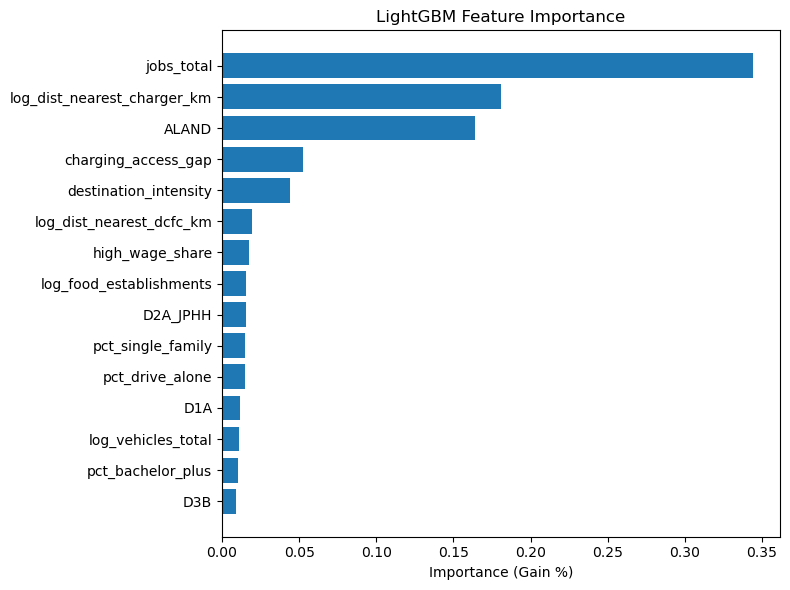

In [12]:
import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(8,6))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance_gain_pct"].head(top_n)[::-1]
)
plt.xlabel("Importance (Gain %)")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()